In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import numpy as np

pad = "Data/etmgeg_310.txt"
df = pd.read_csv(pad, skiprows=51, decimal=",", low_memory=False)
df.columns = df.columns.str.strip()
vlis = df[["YYYYMMDD", "FG", "FHX"]].copy()

#### 1. De enige in Nederland geregistreerde orkaan: 7 september 1944 in Vlissingen

In [4]:
vlis["YYYYMMDD"] = vlis["YYYYMMDD"].astype(str)
vlis["YYYYMMDD"] = pd.to_datetime(vlis["YYYYMMDD"].str.strip(), format="%Y%m%d")
vlis = vlis.loc[vlis["YYYYMMDD"].between("1944-09-06", "1944-09-08")]

In [5]:
vlis[["FG", "FHX"]] = vlis[["FG", "FHX"]].apply(pd.to_numeric, errors="coerce")
vlis["km/u"] = (vlis["FHX"] * 0.1) * 3.6

In [6]:
bins = [0, 1, 5, 11, 19, 28, 38, 49, 61, 74, 88, 102, 117, 200]
labels = ["0-Windstil", "1-Zwak", "2-Zwak", "3-Matig", "4-Matig", "5-Vrij krachtig",
          "6-Krachtig", "7-Hard", "8-Stormachtig", "9-Storm", "10-Zware storm",
          "11-Zeer zware storm", "12-Orkaan"]

vlis["beaufort"] = pd.cut(vlis["km/u"], bins=bins, labels=labels)
vlis

,YYYYMMDD,FG,FHX,km/u,beaufort
14128,1944-09-06,62,98,35.28,5-Vrij krachtig
14129,1944-09-07,118,350,126.00,12-Orkaan
14130,1944-09-08,113,154,55.44,7-Hard


#### 2. Station Vlissingen Jaargemiddelde Temperatuur

In [7]:
vlis_temp = df[["YYYYMMDD", "TG"]].copy()
vlis_temp["YYYYMMDD"] = pd.to_datetime(vlis_temp["YYYYMMDD"], format="%Y%m%d")
vlis_temp["TG"] = pd.to_numeric(vlis_temp["TG"], errors="coerce") * 0.1
vlis_temp = vlis_temp.groupby(vlis_temp["YYYYMMDD"].dt.year)["TG"].mean().reset_index()
vlis_temp["yoy_change"] = vlis_temp["TG"].diff()
vlis_temp["yoy_smooth"] = vlis_temp["TG"].rolling(window=10, center=True).mean()
vlis_temp

,YYYYMMDD,TG,yoy_change,yoy_smooth
0,1906,9.934521,NaN,NaN
1,1907,9.310411,-0.624110,NaN
2,1908,9.118579,-0.191832,NaN
3,1909,8.981918,-0.136661,NaN
4,1910,9.934795,0.952877,NaN
...,...,...,...,...
116,2022,12.543288,1.364384,11.741573
117,2023,12.450959,-0.092329,NaN
118,2024,12.247541,-0.203418,NaN
119,2025,12.185205,-0.062336,NaN


In [9]:
from scipy.stats import linregress

clean = vlis_temp.dropna(subset=["TG"])
slope, intercept, r, p, se = linregress(clean["YYYYMMDD"], clean["TG"])
print(f"Slope: {slope:.4f}/jaar,corr: {r:.2f},  p-waarde: {p:.4f}")

Slope: 0.0158/jaar,corr: 0.60,  p-waarde: 0.0000


In [10]:
early = vlis_temp.loc[vlis_temp["YYYYMMDD"] <= 1980]
late = vlis_temp[vlis_temp["YYYYMMDD"] > 1980]

slope1, _, r1, p1, _ = linregress(early["YYYYMMDD"], early["TG"])
slope2, _, r2, p2, _ = linregress(late["YYYYMMDD"], late["TG"])

print(f"1901-1980: {slope1:.4f} Corr:{r1:.2f}, °C/jaar, p: {p1:.4f}")
print(f"1981-2024: {slope2:.4f} Corr:{r2:.2f}, °C/jaar, p: {p2:.4f}")

1901-1980: 0.0023 Corr:0.08, °C/jaar, p: 0.4909
1981-2024: 0.0363 Corr:0.53, °C/jaar, p: 0.0002


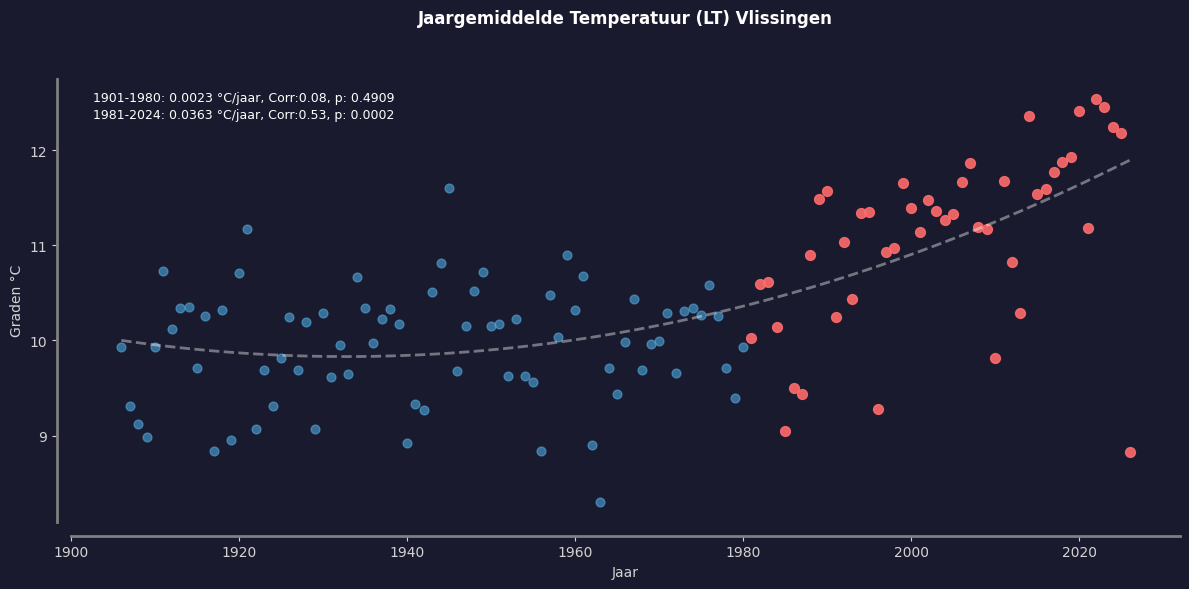

In [11]:
early = vlis_temp.loc[vlis_temp["YYYYMMDD"] <= 1980]
late = vlis_temp.loc[vlis_temp["YYYYMMDD"] > 1980]

fig, ax = plt.subplots(figsize=(12,6))
fig.set_facecolor("#1a1a2e")
ax.set_facecolor("#1a1a2e")

coef = np.polyfit(vlis_temp["YYYYMMDD"], vlis_temp["TG"], deg=2)
trend = np.poly1d(coef)
ax.scatter(early["YYYYMMDD"], early["TG"], s=40, color="#4ea8de", alpha=0.6,  label="Temperatuur", zorder=1)
ax.scatter(late["YYYYMMDD"], late["TG"], s=50, color="#ff6b6b", alpha=0.9, label="Temperatuur", zorder=1)
ax.plot(vlis_temp["YYYYMMDD"], trend(vlis_temp["YYYYMMDD"]), linestyle="--", linewidth=2, color="white",alpha=0.4, label="Trend", zorder=3)

ax.tick_params(colors="lightgrey")
ax.set_ylabel("Graden °C", color="lightgrey")
ax.set_xlabel("Jaar", color="lightgrey")
ax.set_title("Jaargemiddelde Temperatuur (LT) Vlissingen", color="white", fontweight="bold", pad=40)

ax.spines[["top","right"]].set_visible(False)
ax.spines[["left","bottom"]].set_color("grey")
ax.spines[["left","bottom"]].set_position(("outward", 10))
ax.spines[["left","bottom"]].set_linewidth(2)
ax.text(0.02, 0.95, f"1901-1980: {slope1:.4f} °C/jaar, Corr:{r1:.2f}, p: {p1:.4f}",
        transform=ax.transAxes, color="white", fontsize=9)
ax.text(0.02, 0.91, f"1981-2024: {slope2:.4f} °C/jaar, Corr:{r2:.2f}, p: {p2:.4f}",
        transform=ax.transAxes, color="white", fontsize=9)
#plt.savefig("Vlis_temp.png", bbox_inches="tight")
plt.tight_layout()
plt.show()